# **Project Name**    - 🎬 Amazon Prime Video — Exploratory Data Analysis




# **Project Summary -**

The goal of this project is to perform an end-to-end **Exploratory Data Analysis (EDA)** on Amazon Prime Video's catalog of movies and TV shows. Two raw datasets — `titles.csv` (show/movie metadata) and `credits.csv` (cast & crew details) — are combined into a single, analysis-ready dataset, cleaned, and then explored visually to answer real questions about the platform's content strategy.




**Key Steps in this Project**

| # | Step | What happens |
|---|---|---|
| 1 | **Data Wrangling** | Import libraries, load both raw datasets |
| 2 | **Inspection** | View columns/shape of each dataset individually |
| 3 | **Merging** | Join `titles` + `credits` on the common `id` column |
| 4 | **Structural Overview** | Shape, column names, dtypes (`.info()`) of merged data |
| 5 | **Dataset Description** | Document what every column means |
| 6 | **Data Cleaning** | Detect missing values → impute/drop intelligently → remove duplicates |
| 7 | **Univariate Analysis** | Box plots, histograms, bar plots, pie charts on individual columns |
| 8 | **Bivariate Analysis** | Scatter plots, line plots, violin plots between pairs of variables |
| 9 | **Multivariate Analysis** | Pair plot & correlation heatmap across numeric features |
| 10 | **Conclusion** | Summarize insights tied back to the problem statement |

# **GitHub Link -**

https://github.com/KartikJoshi1509/AmazonPrimeEDAKartikJoshi

# **Problem Statement**


Amazon Prime Video hosts a massive, varied library of movies and TV shows sourced from different countries, genres, and eras. Without structured analysis, it's hard to answer basic but important questions about the platform's content strategy. This project explores the catalog through three lenses:

**🎭 Content Diversity** — How diverse is Amazon Prime's content in terms of genres, production countries, content type (Movie vs Show), and age certification? Is the platform dominated by a handful of genres/countries, or is it broadly diversified?

**📈 Trends Over Time** — How has the volume and nature of content evolved across release years? Are more titles being added in recent years? Are runtimes, season counts, or ratings shifting over time?

**⭐ IMDb Ratings** — How are IMDb scores distributed across the platform? Do genre, content type, age certification, or vote count correlate with rating? Which titles/content types stand out as highly rated vs. poorly rated?

Answering these questions helps understand what kind of content performs well and how the catalog has grown and diversified — insights valuable from both a viewer's and a content-strategist's perspective.

# 🎓Business Objectives





## 1. Content Acquisition & Licensing Strategy


Identify which genres, countries, and content types are under-represented, to guide where to license/produce more content and close catalog gaps.

Use the "top-rated titles" and "most-credited people" analysis to spot proven genres, creators, or actor/director partnerships worth prioritizing in future deals.

Decide whether to keep investing heavily in movies or start shifting spend toward TV shows, given how skewed the current catalog is.

## 2. Content Production & Commissioning Decisions

Use the runtime and season-count trends to set target specs for new originals (e.g., "shows should target 2–3 seasons," "movies should stay in the 80–100 min range") based on what already performs well.

Use the age-certification vs. rating pattern to decide whether to greenlight more mature-audience content or invest in improving family-friendly content quality.

## 3. Catalog Growth & Competitive Positioning

Track the release-year distribution over time to benchmark how fast the catalog is growing and whether that pace matches subscriber growth or competitor catalogs (Netflix, Disney+, etc.).

Use the production-country breakdown to evaluate international expansion — e.g., is India/UK content underweighted relative to those markets' subscriber base?

## 4. Quality & Viewer Satisfaction Monitoring

Use the IMDb/TMDb score trends to monitor whether newer originals are maintaining quality compared to older licensed content, as an early-warning signal for content strategy drift.

Use the votes-vs-score correlation to distinguish "popular but mediocre" content from "high-quality but low-visibility" content — useful for recommendation/promotion tuning.

## 5. Marketing & Recommendation Engine Input

Feed genre-popularity and rating-by-genre insights into personalized recommendation weighting or homepage curation.

Use top genre combinations to inform marketing campaigns or thematic content rows (e.g., "Comedy-Drama Picks").

# 🐍 Data Wrangling

## Step 1 — Import Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Load Both Datasets

In [ ]:
data1 = pd.read_csv('titles.csv')   # movie/show metadata
data2 = pd.read_csv('credits.csv')  # cast & crew data

print("Dataset 1 (titles)  shape :", data1.shape)
print("Dataset 2 (credits) shape :", data2.shape)

Dataset 1 (titles)  shape : (9871, 15)
Dataset 2 (credits) shape : (124235, 5)


## Step 3 — Display Columns of Both Datasets

### Import Libraries

In [ ]:
print("Columns in Dataset 1 (titles):")
print(data1.columns.tolist())

print("\nColumns in Dataset 2 (credits):")
print(data2.columns.tolist())

Columns in Dataset 1 (titles):
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']

Columns in Dataset 2 (credits):
['person_id', 'id', 'name', 'character', 'role']


## Step 4 — Merge the Datasets on the Common Column

### Both datasets share the `id` column (a unique identifier for each title), so we merge on it.

In [ ]:
data = pd.merge(data1, data2, on='id', how='inner')

print("Merged Dataset:")
data

Merged Dataset:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124342,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124343,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124344,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124345,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR


## Step 5 — Number of Rows and Columns in the Final Dataset

In [ ]:
print("Number of rows    :", data.shape[0])
print("Number of columns :", data.shape[1])

Number of rows    : 124347
Number of columns : 19


## Step 6 — Display All Column Names of the Final Dataset


In [ ]:
print(data.columns.tolist())

['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score', 'person_id', 'name', 'character', 'role']


## Step 7 - Dataset Info

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124347 non-null  object 
 1   title                 124347 non-null  object 
 2   type                  124347 non-null  object 
 3   description           124256 non-null  object 
 4   release_year          124347 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124347 non-null  int64  
 7   genres                124347 non-null  object 
 8   production_countries  124347 non-null  object 
 9   seasons               8153 non-null    float64
 10  imdb_id               119044 non-null  object 
 11  imdb_score            118296 non-null  float64
 12  imdb_votes            118272 non-null  float64
 13  tmdb_popularity       124332 non-null  float64
 14  tmdb_score            114082 non-null  float64
 15  

# 📖 Dataset Description

The dataset is formed by merging two source files:

- **`titles.csv`** — one row per movie/TV show, describing its metadata.
- **`credits.csv`** — one row per person's involvement (actor/director) in a title.

The final merged dataset has **19 columns**:

| Column | Description |
|---|---|
| `id` | Unique identifier for each title (the key used to merge the two datasets). |
| `title` | Name of the movie or TV show. |
| `type` | Content type — either `MOVIE` or `SHOW`. |
| `description` | Short plot summary/synopsis of the title. |
| `release_year` | Year the title was originally released. |
| `age_certification` | Age rating/certification (e.g., TV-PG, R, PG-13). |
| `runtime` | Duration of a movie (minutes) or average episode runtime for a show. |
| `genres` | List of genres associated with the title (e.g., comedy, drama, action). |
| `production_countries` | Country/countries where the title was produced. |
| `seasons` | Number of seasons (TV shows only; NaN/0 for movies). |
| `imdb_id` | Unique identifier of the title on IMDb. |
| `imdb_score` | IMDb rating of the title (scale of 0–10). |
| `imdb_votes` | Number of votes/ratings the title received on IMDb. |
| `tmdb_popularity` | Popularity score of the title on TMDb (The Movie Database). |
| `tmdb_score` | Average rating of the title on TMDb. |
| `person_id` | Unique identifier for each cast/crew member. |
| `name` | Name of the actor or director/crew member. |
| `character` | Name of the character portrayed (actors only). |
| `role` | Role of the person — either `ACTOR` or `DIRECTOR`. |

---

# 🧹 Missing Values / Null Values

## Step 8 — Display Missing Values in All Columns

In [ ]:
data.isnull().sum()

,0
id,0
title,0
type,0
description,91
release_year,0
age_certification,67640
runtime,0
genres,0
production_countries,0
seasons,116194


### The `seasons` column has null values because it's only applicable to TV shows — movies naturally have no seasons. Rather than dropping these rows, we replace them with `0`.

In [ ]:
# Replace null values in 'seasons' with 0 (movies simply don't have seasons)
data['seasons'] = data['seasons'].fillna(0)

### `age_certification` is a categorical column, so its missing values are best filled with the **mode** (most frequent certification).

In [ ]:
# Replace null values in 'age_certification' with the mode
data['age_certification'] = data['age_certification'].fillna(data['age_certification'].mode()[0])

### `imdb_votes` missing simply means the title has effectively no recorded votes — treat as `0`. `character` is missing whenever the crew member is a director (not an actor) — label these as `'unknown'`.

In [ ]:
# Replace null values in 'imdb_votes' with 0
data['imdb_votes'] = data['imdb_votes'].fillna(0)

# Replace null values in 'character' with 'unknown'
data['character'] = data['character'].fillna('unknown')

### `tmdb_popularity`, `tmdb_score`, and `imdb_score` are continuous numeric ratings/scores — filling with the **mean** preserves the overall distribution better than dropping rows.

In [ ]:
# Replace null values in numeric rating columns with their mean
data['tmdb_popularity'] = data['tmdb_popularity'].fillna(round(data['tmdb_popularity'].mean(), 2))
data['tmdb_score'] = data['tmdb_score'].fillna(round(data['tmdb_score'].mean(), 1))
data['imdb_score'] = data['imdb_score'].fillna(round(data['imdb_score'].mean(), 1))

### `description` and `imdb_id` have relatively few missing values and no sensible way to impute them — these rows are simply dropped.

In [ ]:
# Drop rows where 'description' or 'imdb_id' is missing
data.dropna(subset=['description', 'imdb_id'], inplace=True)

print("Remaining missing values per column:")
data.isnull().sum()

Remaining missing values per column:


,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


## Step 9 — Handling Duplicate Rows

In [ ]:
print("Number of duplicate rows before cleaning:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Number of duplicate rows after cleaning :", data.duplicated().sum())
print("Final cleaned dataset shape             :", data.shape)

Number of duplicate rows before cleaning: 168
Number of duplicate rows after cleaning : 0
Final cleaned dataset shape             : (118854, 19)


In [ ]:
data.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,118854.000000,118854.000000,118854.000000,118854.000000,1.188540e+05,118854.000000,118854.000000,1.188540e+05
mean,1995.694592,96.054453,0.153466,5.968800,2.312887e+04,10.334844,5.997704,3.976869e+05
std,28.010517,29.798646,1.006917,1.238147,8.819975e+04,40.786345,1.252196,5.549632e+05
min,1912.000000,1.000000,0.000000,1.100000,0.000000e+00,0.000164,0.800000,1.000000e+00
25%,1980.000000,83.000000,0.000000,5.200000,2.790000e+02,1.917000,5.400000,3.821300e+04
50%,2009.000000,94.000000,0.000000,6.000000,1.227000e+03,3.960000,6.000000,1.323810e+05
75%,2017.000000,109.000000,0.000000,6.800000,7.040000e+03,8.924000,6.800000,5.633935e+05
max,2022.000000,328.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


# **Summary of data-cleaning steps performed:**

1. **Data Loading & Merging** — `titles.csv` and `credits.csv` were merged on the common `id` column.
2. **Handling Missing Values**
   - `seasons`, `imdb_votes` → filled with `0`
   - `age_certification` → filled with the **mode**
   - `character` → filled with `'unknown'`
   - `imdb_score`, `tmdb_popularity`, `tmdb_score` → filled with their **mean**
   - `description`, `imdb_id` → rows **dropped** (no sensible imputation)
3. **Handling Duplicates** — duplicate rows identified and removed.

✅ The dataset is now clean and ready for exploratory analysis.

---

# 📊 Data Visualization

Data visualization is the graphical representation of information and data. Using visual elements like charts, graphs, and maps gives us an accessible way to see and understand trends, outliers, and patterns hiding in the data.

# 1️⃣ Univariate Analysis

*Examining the distribution of one variable at a time.*

## Box Plot of `imdb_score`

Box plots visualize the distribution, spread, and outliers of a numeric variable.

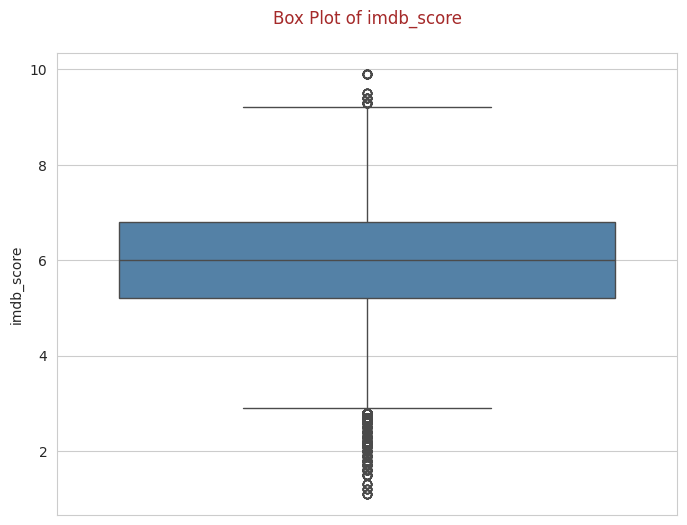

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, y='imdb_score', color='steelblue')
plt.title('Box Plot of imdb_score\n', color='brown')
plt.show()

### **Insights**
- The horizontal line inside the box represents the **median** `imdb_score`, showing the typical rating for content on Amazon Prime.
- Points beyond the whiskers are **outliers** — titles with unusually high or low IMDb scores.

## Box Plot of `runtime`

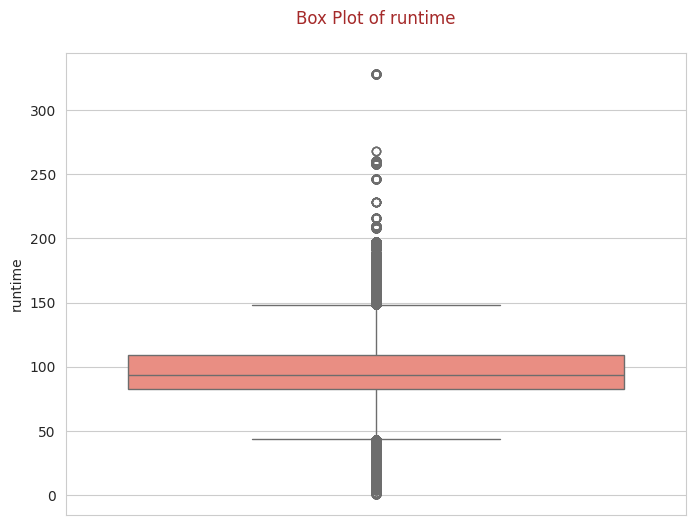

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, y='runtime', color='salmon')
plt.title('Box Plot of runtime\n', color='brown')
plt.show()

### **Insights**
- The median runtime sits close to **90 minutes**, roughly standard for a feature film.
- Several outliers exist on the high end — likely extended cuts, documentaries, or mini-series episodes.

## Histograms

Histograms represent the distribution of a numerical variable, giving a visual sense of the shape of the data.

## Histogram of `release_year`

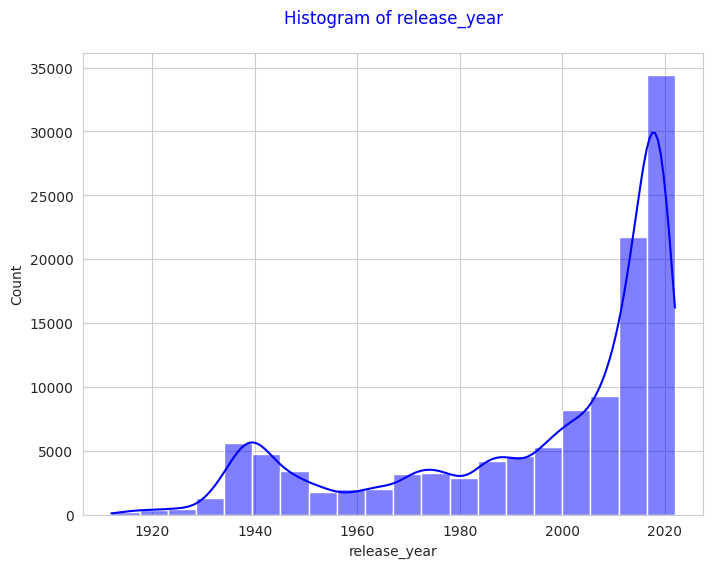

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='release_year', bins=20, color='blue', kde=True)
plt.title('Histogram of release_year\n', color='blue')
plt.show()

### **Insights**
- The distribution is **heavily right-skewed** — the vast majority of titles were released in the last ~15 years.
- There's a sharp uptick after 2010, showing Amazon Prime's catalog has grown rapidly in recent years.

## Histogram of `runtime`

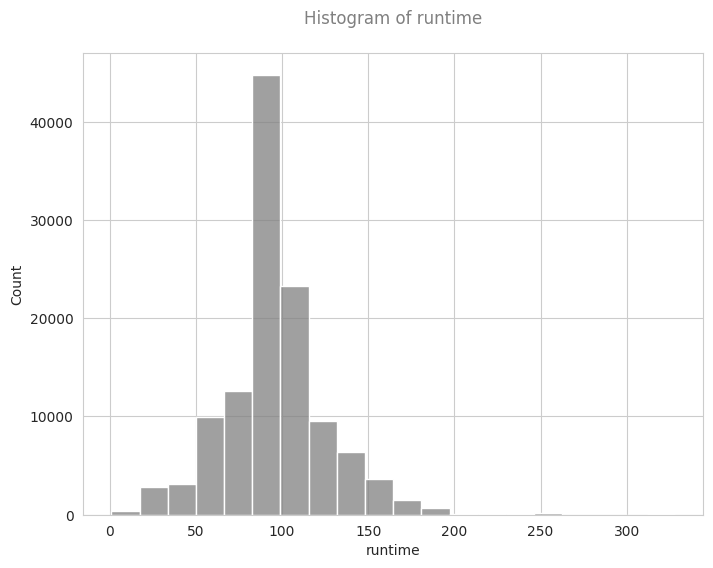

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='runtime', bins=20, color='grey')
plt.title('Histogram of runtime\n', color='grey')
plt.show()

### **Insights**
- Runtime is right-skewed with a peak between **70–90 minutes**.
- Most movies/shows fall between 60–100 minutes — likely the sweet spot balancing storytelling and viewer engagement.

## Histogram of `seasons`

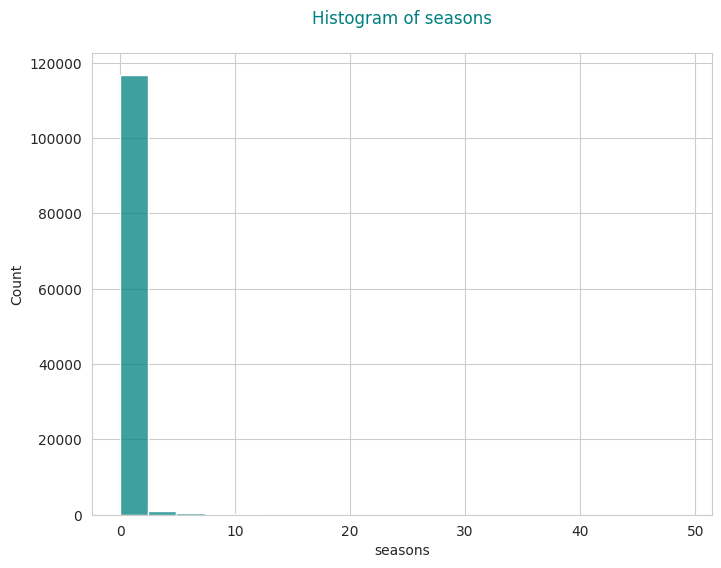

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='seasons', bins=20, color='teal')
plt.title('Histogram of seasons\n', color='teal')
plt.show()

### **Insights**
- The huge spike at 0 reflects **movies** (no seasons) dominating the catalog.
- Among shows that do have seasons, most run for **1–3 seasons**, suggesting many series don't get renewed for long.

## Histogram of `imdb_score`

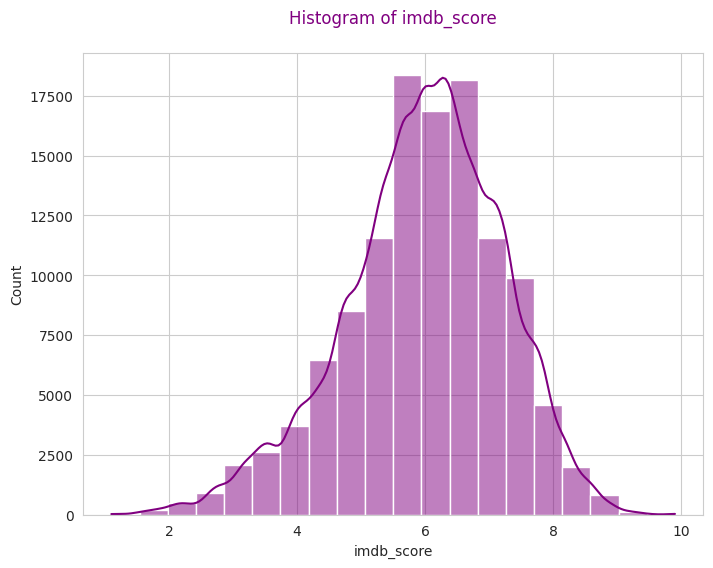

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='imdb_score', bins=20, color='purple', kde=True)
plt.title('Histogram of imdb_score\n', color='purple')
plt.show()

### **Insights**
- The distribution of `imdb_score` is **approximately normal (bell-shaped)**.
- The average IMDb score sits around **6–7**, suggesting the overall quality of Amazon Prime's content is decent, not exceptional.

## Bar Plots / Count Plots

A bar plot presents categorical data as rectangular bars, with length proportional to the value each bar represents.

## Bar Plot of `type` (Movie vs TV Show)

type
MOVIE    111454
SHOW       7400
Name: count, dtype: int64


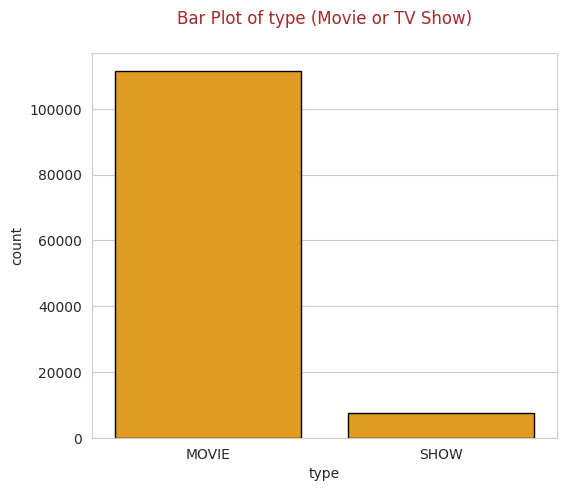

In [ ]:
type_counts = data['type'].value_counts()
print(type_counts)

plt.figure(figsize=(6, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, color='orange', edgecolor='black')
plt.title('Bar Plot of type (Movie or TV Show)\n', color='brown')
plt.ylabel('count')
plt.show()

### **Insights**
- Amazon Prime's catalog is **overwhelmingly dominated by movies** compared to TV shows.
- This suggests Amazon Prime's content acquisition strategy has historically leaned toward films over long-running series.

## Bar Plot of `age_certification`

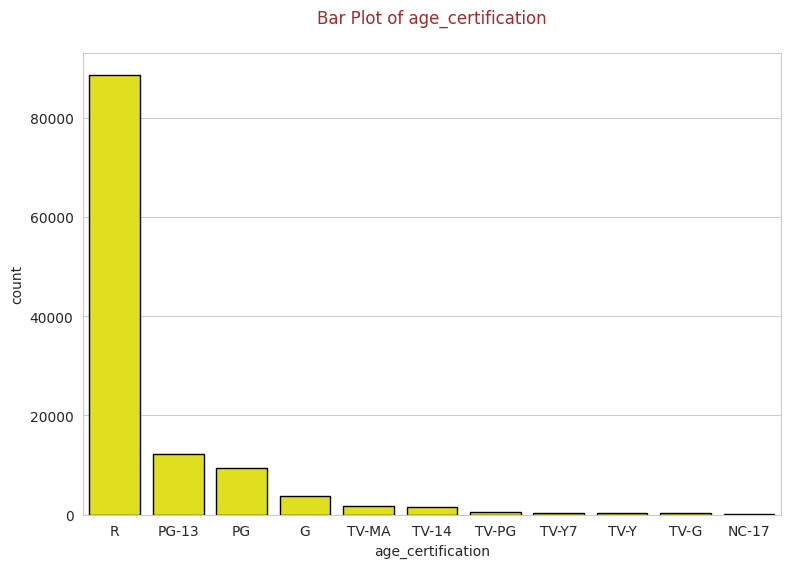

In [ ]:
cert_counts = data['age_certification'].value_counts()

plt.figure(figsize=(9, 6))
sns.barplot(x=cert_counts.index, y=cert_counts.values, color='yellow', edgecolor='black')
plt.title('Bar Plot of age_certification\n', color='brown')
plt.ylabel('count')
plt.xlabel('age_certification')
plt.show()

### **Insights**
- **'R'-rated** content has the highest count by a wide margin, followed by **PG-13**.
- Mature-audience content dominates the catalog — family-friendly (`G`, `TV-Y`, `TV-G`) titles are comparatively rare.

## Bar Plot of `genres` (Top 10)

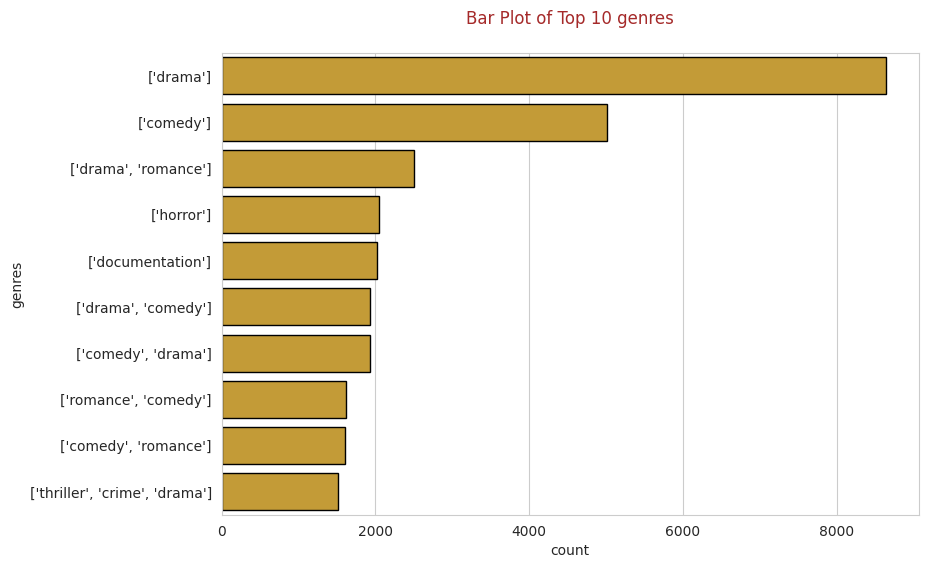

In [ ]:
genre_counts = data['genres'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index.astype(str), color='goldenrod', edgecolor='black')
plt.title('Bar Plot of Top 10 genres\n', color='brown')
plt.xlabel('count')
plt.ylabel('genres')
plt.show()

### **Insights**
- **Drama** and **comedy** are the single most common genre tags, reflecting broadly popular viewer tastes.
- Genre *combinations* like `['drama','romance']` and `['comedy','drama']` are also frequent, showing many titles blend genres rather than sticking to one.

## Bar Plot of `production_countries` (Top 10)

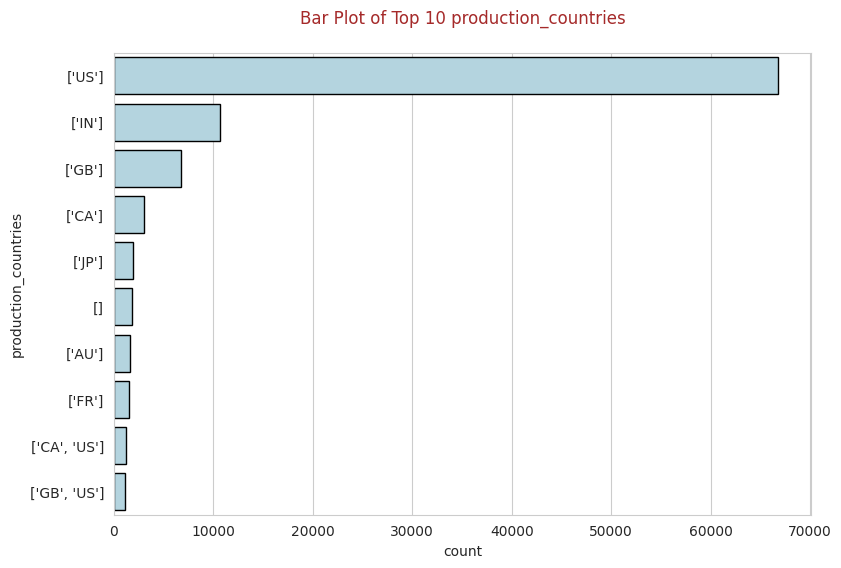

In [ ]:
country_counts = data['production_countries'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=country_counts.values, y=country_counts.index.astype(str), color='lightblue', edgecolor='black')
plt.title('Bar Plot of Top 10 production_countries\n', color='brown')
plt.xlabel('count')
plt.ylabel('production_countries')
plt.show()

### **Insights**
- The **United States** dominates content production by a huge margin.
- **India** and the **United Kingdom** follow as the next-largest contributors — showing Amazon Prime does source a meaningful share of content internationally, but the catalog is still US-centric.

## Bar Plot of Average `imdb_score` by `age_certification`

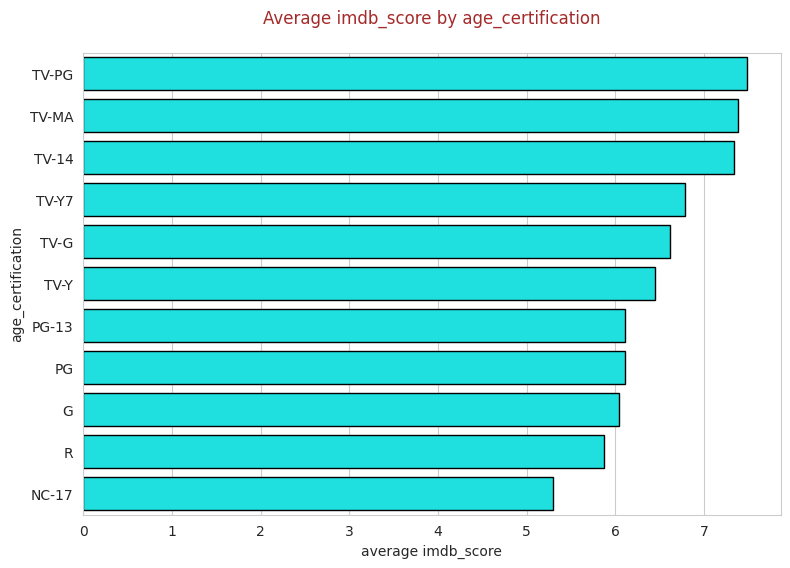

In [ ]:
cert_rating = data.groupby('age_certification')['imdb_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=cert_rating.values, y=cert_rating.index, color='cyan', edgecolor='black')
plt.title('Average imdb_score by age_certification\n', color='brown')
plt.xlabel('average imdb_score')
plt.show()

### **Insights**
- Content aimed at **mature audiences** tends to score slightly higher on average than family-oriented content.
- This could reflect more ambitious storytelling in mature titles, or simply a smaller, more curated sample size for niche family-rating categories.

## Pie Charts

A pie chart visualizes the proportions of different categories within a whole. Each slice represents a category, sized proportionally to its share.

## Pie Chart of `type`

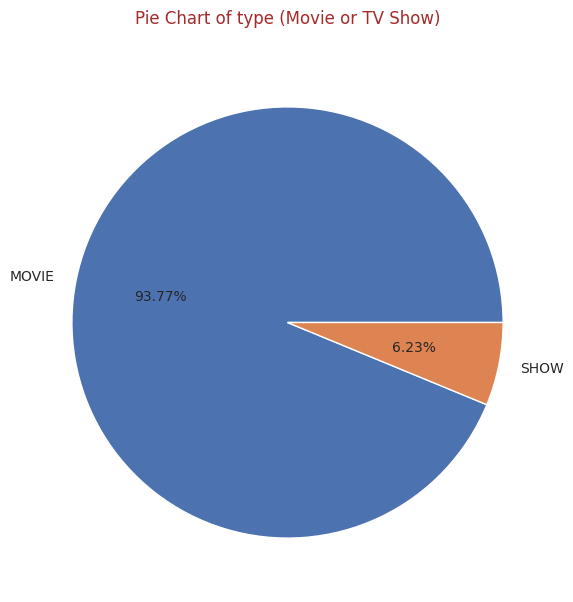

In [ ]:
type_counts = data['type'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%.2f%%', colors=['#4C72B0', '#DD8452'])
plt.title('Pie Chart of type (Movie or TV Show)\n', color='brown')
plt.show()

### **Insights**
- Movies make up roughly **9 out of every 10 titles** on the platform — a clear content-diversity gap between movies and shows.

## Pie Chart of `age_certification` *(interactive — Plotly)*

In [ ]:
fig = px.pie(values=cert_counts.values, names=cert_counts.index,
             title='Pie Chart of age_certification')
fig.show()

### **Insights**
- **R-rated** titles alone account for the largest single wedge of the certification pie — reinforcing the mature-audience skew seen in the bar plot above.

---

# 2️⃣ Bivariate Analysis

*Examining the relationship between two variables at a time.*

## Scatter Plot — `imdb_votes` vs `imdb_score`

A scatter plot uses dots to represent the values of two numeric variables — ideal for spotting relationships between them.

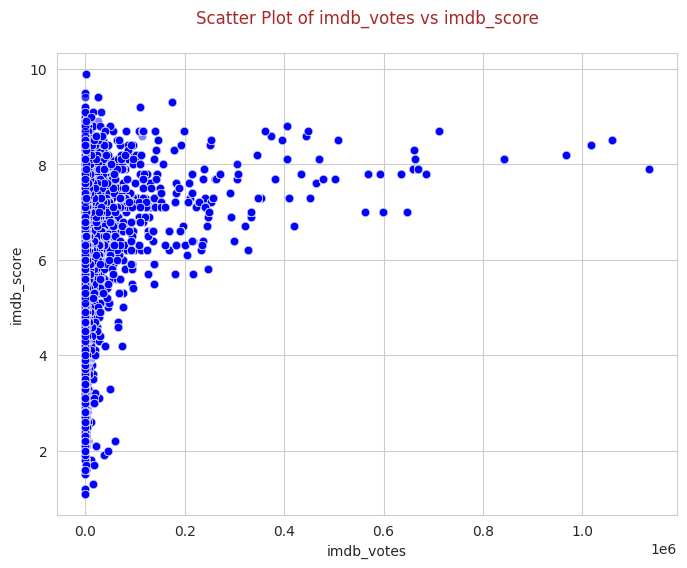

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='imdb_votes', y='imdb_score', color='blue', alpha=0.5)
plt.title('Scatter Plot of imdb_votes vs imdb_score\n', color='brown')
plt.show()

### **Insights**
- There's a **positive correlation**: titles with more votes tend to have higher IMDb scores.
- This suggests that popular, widely-watched titles are also generally well-received — or that highly-rated titles attract more viewers who then vote.

## Line Plots Over Time

### `runtime` vs `release_year`

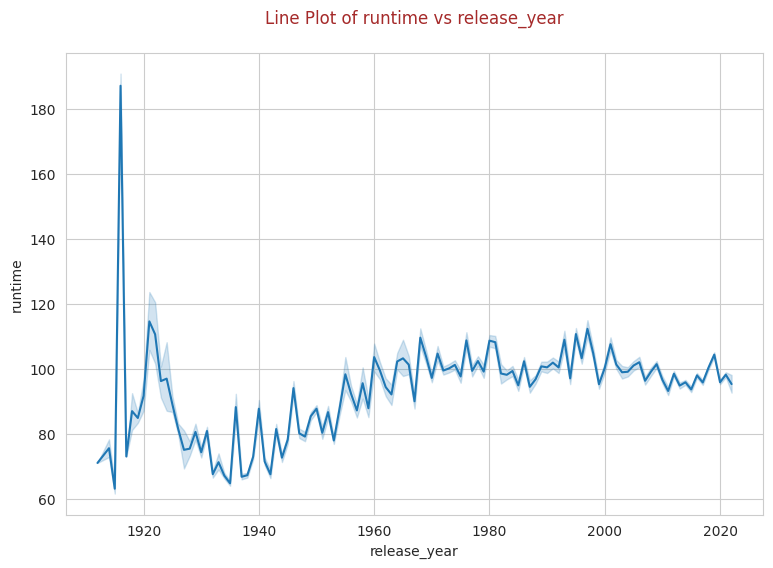

In [ ]:
plt.figure(figsize=(9, 6))
sns.lineplot(data=data, x='release_year', y='runtime')
plt.title('Line Plot of runtime vs release_year\n', color='brown')
plt.show()

### **Insights**
- There is a **slight downward trend** in average runtime over the decades — movies and shows have been getting a little shorter over time.

### `seasons` vs `release_year`

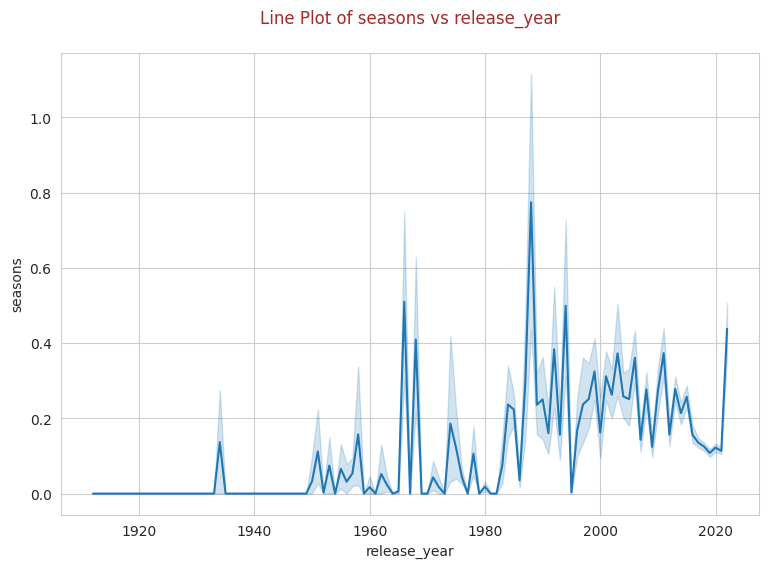

In [ ]:
plt.figure(figsize=(9, 6))
sns.lineplot(data=data, x='release_year', y='seasons')
plt.title('Line Plot of seasons vs release_year\n', color='brown')
plt.show()

### **Insights**
- There's an **upward trend** in the number of seasons for TV shows in more recent years — shows are being renewed for longer runs, suggesting growing viewer investment in serialized content.

### `imdb_score` vs `release_year`

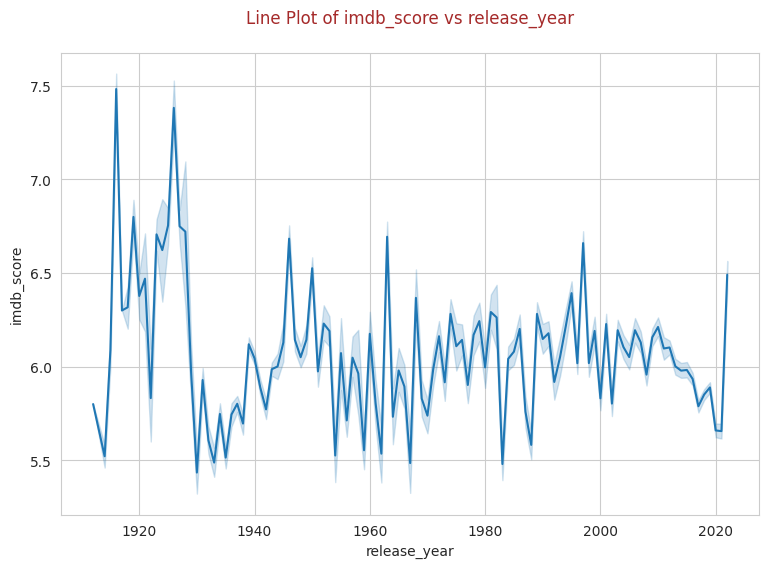

In [ ]:
plt.figure(figsize=(9, 6))
sns.lineplot(data=data, x='release_year', y='imdb_score')
plt.title('Line Plot of imdb_score vs release_year\n', color='brown')
plt.show()

### **Insights**
- A **slight downward trend** in average IMDb score over the years suggests older titles on the platform tend to be rated somewhat higher than newer releases — possibly reflecting nostalgia bias, survivorship bias (only well-regarded old films get re-licensed), or genuinely evolving viewer tastes.

### `tmdb_score` vs `release_year`

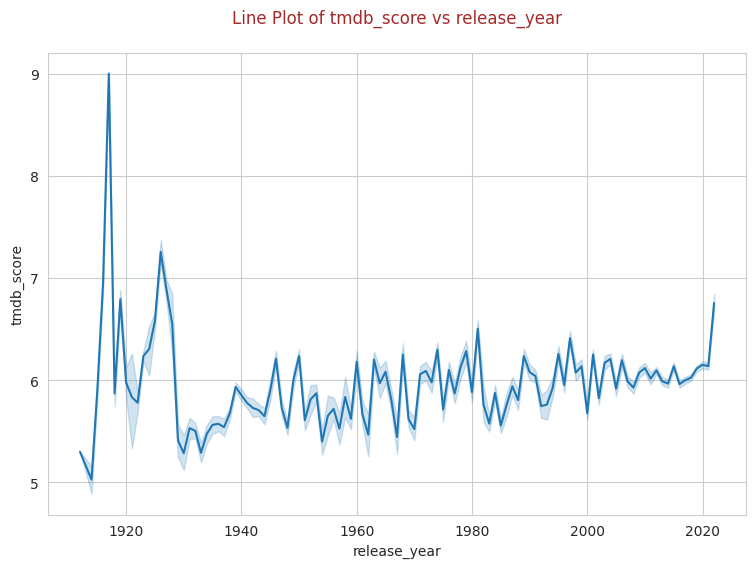

In [ ]:
plt.figure(figsize=(9, 6))
sns.lineplot(data=data, x='release_year', y='tmdb_score')
plt.title('Line Plot of tmdb_score vs release_year\n', color='brown')
plt.show()

### **Insights**
- `tmdb_score` shows a broadly similar pattern to `imdb_score`, reinforcing that the rating dip for newer titles is consistent across platforms, not an IMDb-specific quirk.

## Violin Plot — `imdb_score` by `type`

A violin plot combines a box plot with a rotated kernel density plot, showing the full distribution shape of a numeric variable for each category.Answer Here

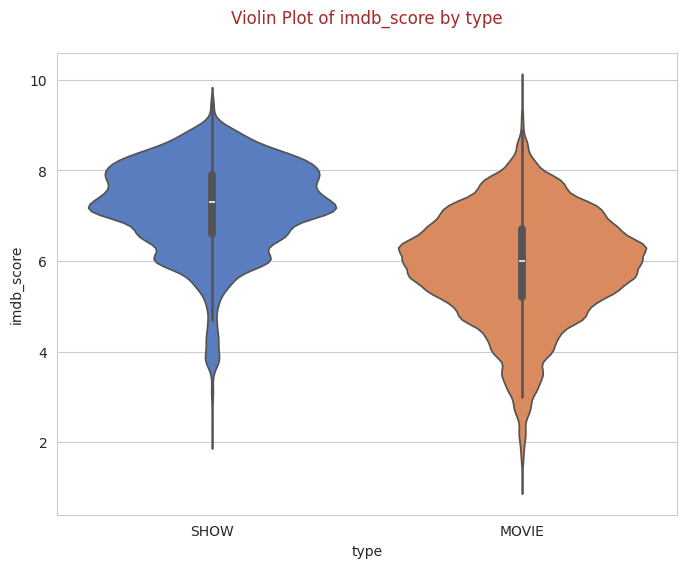

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=data, x='type', y='imdb_score', palette='muted')
plt.title('Violin Plot of imdb_score by type\n', color='brown')
plt.show()

### **Insights**
- **TV shows** tend to have a slightly higher median `imdb_score` than movies — series that get renewed have likely already proven themselves with audiences.
- Movies show a wider spread with a longer lower tail, reflecting a larger volume of low-rated/niche titles.

---

# 3️⃣ Multivariate Analysis

*Examining relationships across several numeric variables at once.*

## Pair Plot

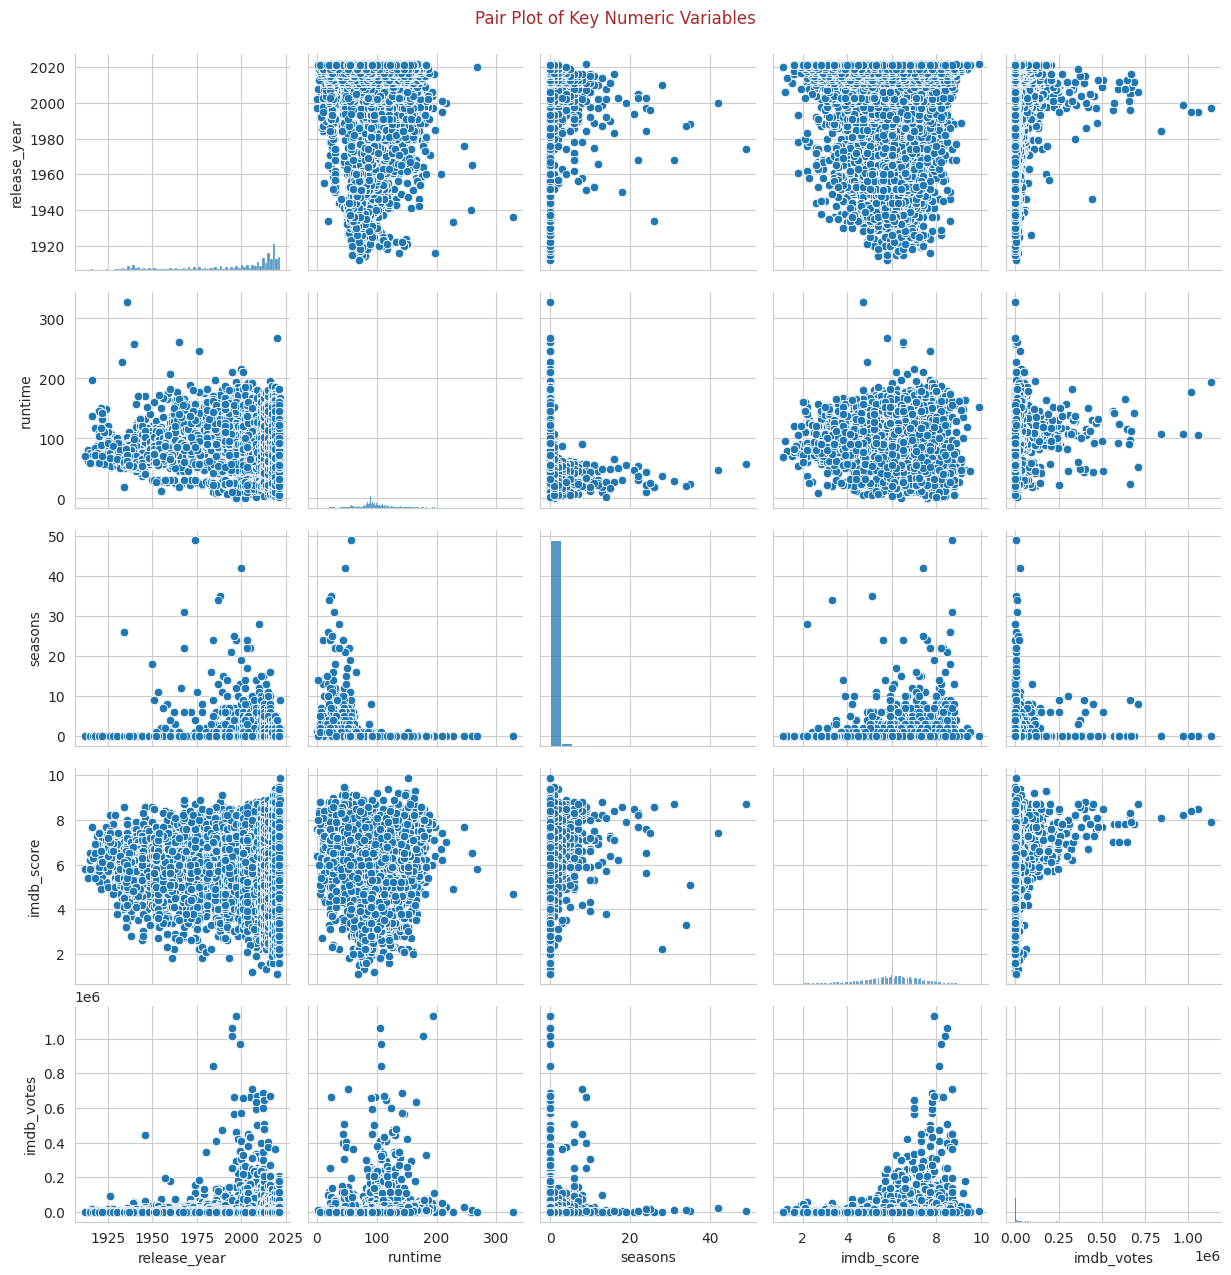

In [ ]:
num_cols_for_pairplot = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes']
sns.pairplot(data[num_cols_for_pairplot])
plt.suptitle('Pair Plot of Key Numeric Variables', y=1.02, color='brown')
plt.show()

### **Insights**
- Confirms the positive `imdb_votes`–`imdb_score` relationship seen earlier.
- `release_year` is clustered heavily toward recent years, visually reinforcing the catalog's recency skew.

## Correlation Heatmap

A heatmap uses color intensity to represent the strength of relationships (correlation) between numeric variables in a dataset.

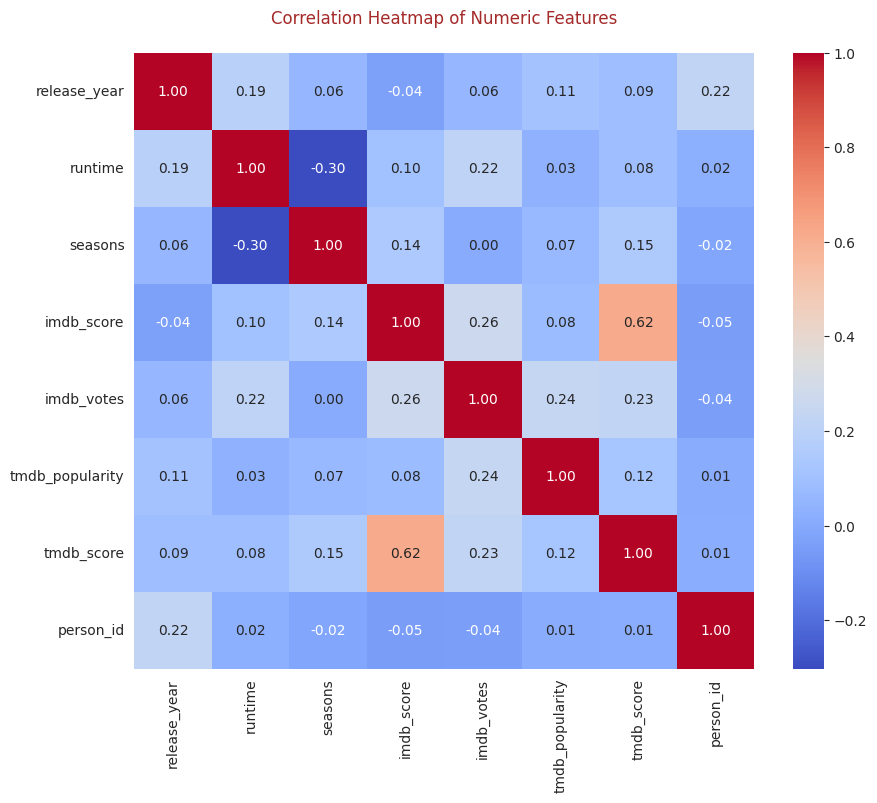

In [ ]:
num_col = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(num_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features\n', color='brown')
plt.show()

### **Insights**
- `imdb_score` and `imdb_votes` show a **mild positive correlation**, echoing the scatter plot.
- `imdb_score` and `tmdb_score` are **strongly correlated** — as expected, since both measure roughly the same thing (audience-perceived quality) via different platforms.
- Most other numeric pairs (e.g., `release_year` vs `runtime`) show **weak correlation**, indicating those variables move fairly independently of each other.

---

### ✨ Bonus: A Few Extra Cuts of the Data

A couple of additional angles that round out the "content diversity" and "top performers" picture.

## Top 10 Highest-Rated Titles on Amazon PrimeAnswer Here

In [ ]:
top_rated = (
    data[['title', 'type', 'release_year', 'imdb_score', 'imdb_votes']]
    .drop_duplicates(subset='title')
    .sort_values(by=['imdb_score', 'imdb_votes'], ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_rated

,title,type,release_year,imdb_score,imdb_votes
0,Pawankhind,MOVIE,2022,9.9,2036.0
1,Couple of Mirrors,SHOW,2021,9.5,99.0
2,The Chosen,SHOW,2019,9.4,25538.0
3,Tari Sathe,MOVIE,2021,9.4,517.0
4,Jai Bhim,MOVIE,2021,9.3,175187.0
5,Soorarai Pottru,MOVIE,2020,9.2,109759.0
6,Quota,MOVIE,2020,9.2,306.0
7,Alexander Babu: Alex in Wonderland,MOVIE,2019,9.2,81.0
8,Clarkson's Farm,SHOW,2021,9.1,31981.0
9,Peranbu,MOVIE,2019,9.1,14708.0


## Genre Diversity — How Many Unique Genre Combinations Exist?

In [ ]:
n_unique_genres = data['genres'].nunique()
n_unique_countries = data['production_countries'].nunique()

print(f"Unique genre combinations       : {n_unique_genres}")
print(f"Unique production-country combos: {n_unique_countries}")

Unique genre combinations       : 1961
Unique production-country combos: 472


### **Insight** — A large number of unique genre and country combinations shows that, beneath the dominant drama/comedy and US-heavy averages, Amazon Prime's catalog is actually quite long-tailed and diverse when you look past the top few categories.

## Top 10 Most Frequently Credited People (Actors & Directors)

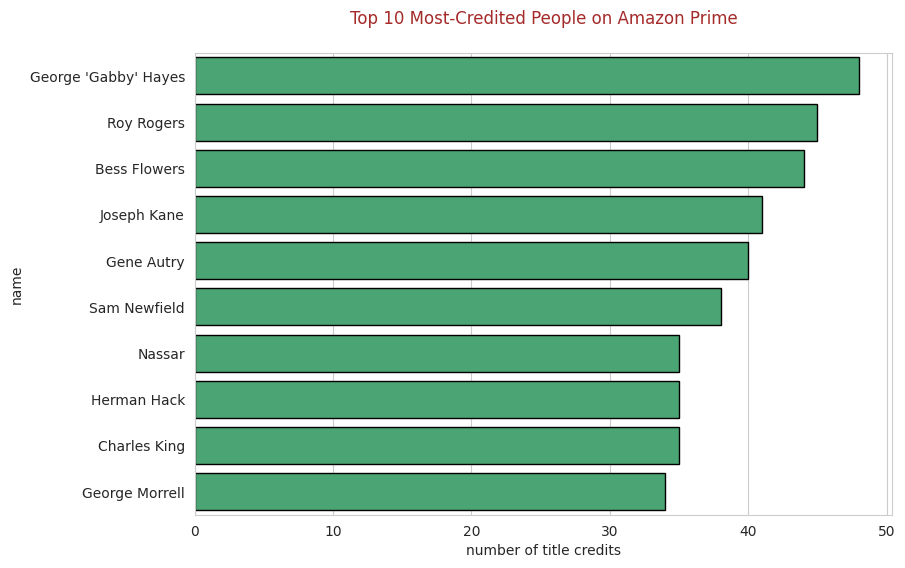

In [ ]:
top_people = data['name'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_people.values, y=top_people.index, color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Most-Credited People on Amazon Prime\n', color='brown')
plt.xlabel('number of title credits')
plt.show()

### **Insight** — These are the actors/directors with the most title credits in the dataset — a proxy for who Amazon Prime's catalog leans on most heavily in front of and behind the camera.

---

# ✅ Conclusion

This Exploratory Data Analysis (EDA) of the Amazon Prime Video dataset has provided valuable insights into the platform's content, trends, and rating patterns — directly addressing the three questions posed in the problem statement.

**🎭 Content Diversity**
- Amazon Prime Video **favors movies over TV shows** by a wide margin (~90%+ of titles are movies).
- **Drama and comedy** are the most prevalent genres, though the long tail of genre *combinations* shows real diversity beneath the top categories.
- The **United States dominates** content production, followed by **India** and the **United Kingdom** — meaningful but modest international representation.
- The catalog skews toward **mature-audience (R-rated)** content over family-friendly titles.

**📈 Trends Over Time**
- The size of the catalog has **grown sharply** in the last ~15 years.
- Movie **runtimes have slightly decreased** over time, while TV shows have seen a **rise in number of seasons**, indicating a shift toward longer-form, serialized viewer engagement.
- **Older titles trend toward slightly higher ratings** than newer releases on both IMDb and TMDb — a pattern worth further investigation (nostalgia bias vs. genuine quality shifts).

**⭐ IMDb Ratings**
- The typical IMDb score sits around **6–7**, roughly normally distributed — the catalog's overall quality is solid but not exceptional.
- **More-voted titles tend to be better-rated**, a positive correlation confirmed across the scatter plot, pair plot, and heatmap.
- **TV shows edge out movies** slightly in median rating, likely reflecting the "renewal survivorship" effect — only shows that already please audiences get more seasons.

Overall, this EDA has successfully uncovered patterns and trends in the Amazon Prime Video dataset, offering valuable information for content creators, platform strategists, and viewers alike. Further analysis — genre-level rating breakdowns, seasonal release patterns, or director/actor-level rating trends — could provide even richer insights for future decision-making.